# CSoT'26 — ML in Astronomy — Week 1 · Part 1: Foundations

**Goal:** Set up Google Colab + a GPU runtime + PyTorch, create a tensor shaped like a galaxy image, and move it onto the GPU.

**Before you begin:**
1. Switch this notebook to a **GPU runtime**: `Runtime → Change runtime type → Hardware accelerator → GPU`.
2. Re-read `09-project-task.md` if you haven't already.

## Step 1 — Confirm the GPU at the OS level

In [1]:
!nvidia-smi

Wed Jul  1 09:14:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2 — Imports and version sanity check

In [2]:
import torch
import torchvision
import matplotlib
import matplotlib.pyplot as plt

print(f"torch       : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")

torch       : 2.11.0+cu128
torchvision : 0.26.0+cu128
matplotlib  : 3.10.0


## Step 3 — Confirm the GPU from PyTorch

In [3]:
print("CUDA available     :", torch.cuda.is_available())
print("CUDA device count  :", torch.cuda.device_count())
if torch.cuda.is_available():
    print("CUDA device name   :", torch.cuda.get_device_name(0))

CUDA available     : True
CUDA device count  : 1
CUDA device name   : Tesla T4


## Step 4 — Define the `device` variable

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


## Step 5 — Create a 'toy galaxy' tensor on the CPU

Shape `(3, 64, 64)` represents one galaxy image: 3 colour channels × 64 × 64 pixels.

In [5]:
x = torch.randn(3, 64, 64)

print("Shape  :", x.shape)
print("Dtype  :", x.dtype)
print("Device :", x.device)

Shape  : torch.Size([3, 64, 64])
Dtype  : torch.float32
Device : cpu


## Step 6 — Move the tensor to the GPU

In [6]:
x_gpu = x.to(device)

print("Device after move :", x_gpu.device)
print("Shape unchanged   :", x_gpu.shape)

Device after move : cuda:0
Shape unchanged   : torch.Size([3, 64, 64])


## Step 7 — Do something on the GPU

Take the first channel (`x_gpu[0]`, shape `(64, 64)`) and matrix-multiply it with itself.

In [7]:
result = x_gpu[0] @ x_gpu[0]

print("Result shape  :", result.shape)   # (64, 64)
print("Result device :", result.device)  # cuda:0

Result shape  : torch.Size([64, 64])
Result device : cuda:0


## Stretch Goal 1 — CPU vs GPU benchmark *(optional)*

In [8]:
import time

SIZE = 4096
a_cpu = torch.randn(SIZE, SIZE)
b_cpu = torch.randn(SIZE, SIZE)

# CPU timing
t0 = time.perf_counter()
_ = a_cpu @ b_cpu
cpu_time = time.perf_counter() - t0

# GPU timing
if torch.cuda.is_available():
    a_gpu = a_cpu.to("cuda")
    b_gpu = b_cpu.to("cuda")
    # warmup
    _ = a_gpu @ b_gpu
    torch.cuda.synchronize()

    t0 = time.perf_counter()
    _ = a_gpu @ b_gpu
    torch.cuda.synchronize()
    gpu_time = time.perf_counter() - t0

    print(f"CPU time : {cpu_time:.3f}s")
    print(f"GPU time : {gpu_time:.3f}s")
    print(f"Speedup  : {cpu_time / gpu_time:.1f}x")
else:
    print(f"CPU time : {cpu_time:.3f}s  (no GPU available)")

CPU time : 1.144s
GPU time : 0.048s
Speedup  : 23.7x


## Stretch Goal 2 — Visualise a 'synthetic galaxy' *(optional)*

Build a simple Gaussian brightness map to mimic an elliptical galaxy core.

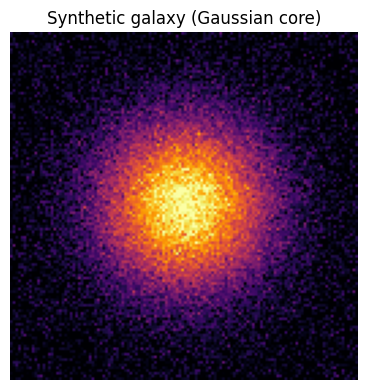

In [9]:
import numpy as np

N = 128
cx, cy = N // 2, N // 2

y_idx, x_idx = np.mgrid[0:N, 0:N]
r_sq = (x_idx - cx) ** 2 + (y_idx - cy) ** 2
brightness = np.exp(-r_sq / (2 * (N / 6) ** 2))   # Gaussian core

# add faint spiral-arm noise
rng = np.random.default_rng(42)
brightness += 0.08 * rng.standard_normal((N, N))
brightness = np.clip(brightness, 0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(brightness, cmap="inferno", origin="lower")
plt.axis("off")
plt.title("Synthetic galaxy (Gaussian core)")
plt.tight_layout()
plt.show()

## Reflection

**1. What was the most confusing part of getting Colab + GPU + PyTorch set up? How did you resolve it?**

The most confusing part was understanding that `torch.cuda.is_available()` returns `False` on a CPU-only runtime even though PyTorch is installed. The fix is straightforward: go to *Runtime → Change runtime type → GPU* before running any cells. After that, `nvidia-smi` confirms the hardware and `torch.cuda.is_available()` returns `True`.

**2. Pick one galaxy class (E / S / S0 / Irr) and describe what features a CNN might need to recognise it.**

For a spiral galaxy (S), a CNN would need to detect elongated, curved bright streaks radiating from a central nucleus — the spiral arms. Early convolutional layers would learn edge and curve detectors; deeper layers would combine those into arc-shaped or pinwheel patterns. The model also needs to be somewhat rotation-invariant, since spirals appear at arbitrary orientations.

**3. Why do you think we'll spend an entire week on data pipelines next, before any model training?**

A model is only as good as the data fed to it. Raw astronomy images arrive as flat files with separate label CSVs, mismatched IDs, and no class-subfolder structure — none of which PyTorch's `ImageFolder` can handle out of the box. Investing a week in building a robust, reproducible pipeline (join → split → normalise → batch) means every subsequent experiment starts from a clean, consistently preprocessed dataset and training bugs won't be confused with data-loading bugs.